In [1]:
import os
import time
import joblib
import pandas as pd
import numpy as np
import pyswarms as ps
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from tensorflow.keras.models import load_model

In [3]:
# ----------------------------------------------------
# 1. 앙상블 모델 및 스케일러 로딩
# ----------------------------------------------------
N_ENSEMBLE = 10
TARGET_NAMES = ["Deflection(mm)", "Weight(kg)"]
MODEL_PATHS = [f'saved_models/pv_ensemble_model_{i+1}.keras' for i in range(N_ENSEMBLE)]
SCALER_DIR = '.' # 스케일러 디렉토리 경로

print("--- 앙상블 모델 및 스케일러 로딩 시작 ---")

try:
    ENSEMBLE_MODELS = [load_model(path) for path in MODEL_PATHS]
except Exception as e:
    print(f"오류: 앙상블 모델 로드 실패. ({e})")
    ENSEMBLE_MODELS = [] 

try:
    X_SCALER_LOADED = joblib.load(os.path.join(SCALER_DIR, 'scaler_X_pvmodule.joblib')) 
    Y_SCALER_LOADED = joblib.load(os.path.join(SCALER_DIR, 'scaler_y_pvmodule.joblib')) 
    
    Y_CENTERS = Y_SCALER_LOADED.center_
    Y_STDS = Y_SCALER_LOADED.scale_
except Exception as e:
    print(f"오류: 스케일러 로드 실패. ({e})")
    raise

print("앙상블 모델 및 스케일러 로딩 완료.")

--- 앙상블 모델 및 스케일러 로딩 시작 ---
앙상블 모델 및 스케일러 로딩 완료.


C:\Users\admin\anaconda3\envs\py31010_auto\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
# ----------------------------------------------------
# 1. 제약 조건 및 타겟 설정
# ----------------------------------------------------
TARGET_NAMES = ["Deflection(mm)", "Weight(kg)"]
CONSTRAINTS = {
    "Deflection(mm)": {"min": None, "max": 12.3}, 
    "Weight(kg)": {"min": None, "max": 3.6}       
}
PENALTY_CONST = 100.0

In [6]:
# ----------------------------------------------------
# 3. PSO용 목적 함수 (가중치 인자를 받도록 래핑)
# ----------------------------------------------------
def objective_for_PSO_constrained(X, current_weights):
    n_particles = X.shape[0]
    F_obj_values = []
    
    # 변위(음수)는 "최대화(+1)", 무게(양수)는 "최소화(-1)"
    GOAL_SIGNS = np.array([1, -1]) 
    
    for i in range(n_particles):
        a, b, c, d, e = X[i, :] # 5차원
        X_input = np.array([[a, b, c, d, e]])
        X_scaled = X_SCALER_LOADED.transform(X_input)
        
        # 앙상블 평균 예측 (원본 물리적 값 반환)
        preds_raw = [model.predict(X_scaled, verbose=0)[0] for model in ENSEMBLE_MODELS]
        y_pred_mean_raw = np.mean(np.array(preds_raw), axis=0)
        
        # 가중치를 공평하게 곱해주기 위해 예측값을 스케일 공간으로 변환
        y_pred_mean_scaled = Y_SCALER_LOADED.transform(y_pred_mean_raw.reshape(1, -1))[0]
        
        # 전달받은 무작위 가중치 반영
        F_obj_unpenalized = np.sum(GOAL_SIGNS * current_weights * y_pred_mean_scaled)
        
        # 제약 조건 검사 및 벌칙 적용 (원본 물리적 값 기준)
        penalty = 0.0
        for j, target_name in enumerate(TARGET_NAMES):
            value = y_pred_mean_raw[j]
            
            # 처짐량은 절댓값으로 변환하여 검사
            if target_name == "Deflection(mm)":
                check_value = abs(value)
            else:
                check_value = value
                
            if target_name in CONSTRAINTS:
                max_req = CONSTRAINTS[target_name]["max"]
                if max_req is not None and check_value > max_req:
                    penalty += PENALTY_CONST * (check_value - max_req)
        
        F_obj_constrained = F_obj_unpenalized - penalty
        F_obj_values.append(F_obj_constrained)
        
    # Pyswarms는 최소화를 수행하므로 부호 반전
    return -np.array(F_obj_values)

# ----------------------------------------------------
# 4. PSO 민감도 분석 함수 정의
# ----------------------------------------------------
def run_pso_robustness_analysis(tolerance, n_runs, pbounds, n_particles, n_iters):
    results_list = []
    print(f"\n[시작] PSO 가중치 변동 허용 오차: ±{tolerance*100:.0f}% (총 {n_runs}회 반복)")

    for run in range(n_runs):
        # 1. 가중치 무작위 샘플링 (W_1, W_2 2개)
        random_weights = np.random.uniform(
            low=BASE_WEIGHT * (1 - tolerance), 
            high=BASE_WEIGHT * (1 + tolerance), 
            size=2
        )

        # 2. PSO 실행 (5차원)
        optimizer_pso = ps.single.GlobalBestPSO(
            n_particles=n_particles,
            dimensions=5,
            options=options,
            bounds=pbounds,
            init_pos=None
        )
        
        cost, pos = optimizer_pso.optimize(
            lambda X: objective_for_PSO_constrained(X, random_weights), 
            iters=n_iters,
            verbose=False # 출력 콘솔이 너무 지저분해지는 것을 방지
        )
        
        # 3. 결과 저장 (-cost로 최대화 값 복원)
        best_params = {
            'a': pos[0], 'b': pos[1], 'c': pos[2], 'd': pos[3], 'e': pos[4]
        }
        
        result_dict = {
            'Run': run + 1,
            'Tolerance': tolerance,
            'Best_F_obj': -cost 
        }
        result_dict.update(best_params)

        for i, w in enumerate(random_weights):
            result_dict[f'W_{i+1}'] = w

        results_list.append(result_dict)
        
        if (run + 1) % 10 == 0:
            print(f"  Run {run+1} 완료...")
    
    print(f"[완료] ±{tolerance*100:.0f}% 분석 완료.")
    return pd.DataFrame(results_list)

# ----------------------------------------------------
# 5. 분석 시나리오 실행
# ----------------------------------------------------
all_pso_analysis_results = []
start_total = time.time()

print("="*50)
print("  🚀 PV 모듈 PSO 가중치 민감도 분석 시작")
print("="*50)

for tolerance in TOLERANCES_TO_ANALYZE:
    df_result = run_pso_robustness_analysis(tolerance, N_RUNS, bounds, N_PARTICLES, N_ITERS)
    all_pso_analysis_results.append(df_result)
    
    tolerance_percent = int(tolerance * 100)
    file_name = os.path.join(OUTPUT_DIR, f'pso_robustness_results_{tolerance_percent}pct_pv.csv')
    df_result.to_csv(file_name, index=False)
    print(f"-> 저장 완료: '{file_name}'")

print(f"\n--- PSO 전체 민감도 분석 완료 ({time.time() - start_total:.2f}초) ---")

  🚀 PV 모듈 PSO 가중치 민감도 분석 시작

[시작] PSO 가중치 변동 허용 오차: ±5% (총 50회 반복)
  Run 10 완료...
  Run 20 완료...
  Run 30 완료...
  Run 40 완료...
  Run 50 완료...
[완료] ±5% 분석 완료.
-> 저장 완료: 'robustness_analysis_PSO_PV\pso_robustness_results_5pct_pv.csv'

[시작] PSO 가중치 변동 허용 오차: ±10% (총 50회 반복)
  Run 10 완료...
  Run 20 완료...
  Run 30 완료...
  Run 40 완료...
  Run 50 완료...
[완료] ±10% 분석 완료.
-> 저장 완료: 'robustness_analysis_PSO_PV\pso_robustness_results_10pct_pv.csv'

[시작] PSO 가중치 변동 허용 오차: ±20% (총 50회 반복)
  Run 10 완료...
  Run 20 완료...
  Run 30 완료...
  Run 40 완료...
  Run 50 완료...
[완료] ±20% 분석 완료.
-> 저장 완료: 'robustness_analysis_PSO_PV\pso_robustness_results_20pct_pv.csv'

[시작] PSO 가중치 변동 허용 오차: ±50% (총 50회 반복)
  Run 10 완료...
  Run 20 완료...
  Run 30 완료...
  Run 40 완료...
  Run 50 완료...
[완료] ±50% 분석 완료.
-> 저장 완료: 'robustness_analysis_PSO_PV\pso_robustness_results_50pct_pv.csv'

--- PSO 전체 민감도 분석 완료 (57992.76초) ---



=== 최종 PSO 강건성 비교 요약 ===
-----------------------------------------------------------------------------------------
  Tolerance | F_obj Mean | F_obj Std | F_obj CV (%) | X_best Avg CV (%) (a, b, c, d, e)
-----------------------------------------------------------------------------------------
  ±05%     |   0.3473  |   0.0763 |   21.98%       |    7.89%
  ±10%     |   0.3551  |   0.0902 |   25.39%       |    7.68%
  ±20%     |   0.3582  |   0.1059 |   29.57%       |    7.71%
  ±50%     |   0.4201  |   0.2233 |   53.16%       |    8.08%
-----------------------------------------------------------------------------------------

   🐝 PSO 결과 기반: 입력 변수(a~e) 가중치 민감도 분석 (Regression)


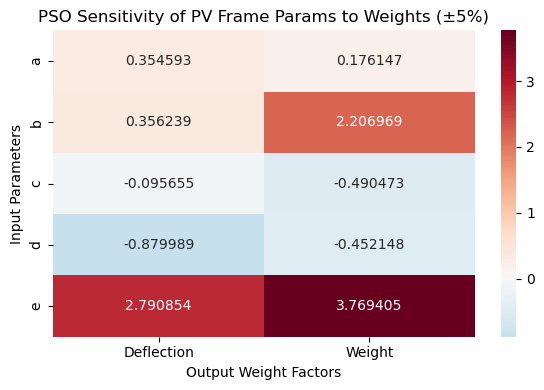

[±5%] 변수 a -> 'Deflection' 가중치에 가장 민감 (계수: 0.354593)
[±5%] 변수 b -> 'Weight' 가중치에 가장 민감 (계수: 2.206969)
[±5%] 변수 c -> 'Weight' 가중치에 가장 민감 (계수: -0.490473)
[±5%] 변수 d -> 'Deflection' 가중치에 가장 민감 (계수: -0.879989)
[±5%] 변수 e -> 'Weight' 가중치에 가장 민감 (계수: 3.769405)


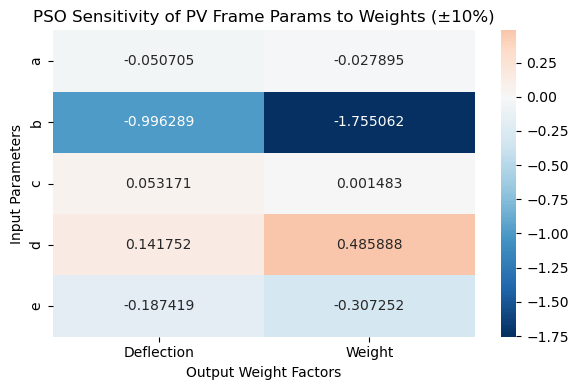

[±10%] 변수 a -> 'Deflection' 가중치에 가장 민감 (계수: -0.050705)
[±10%] 변수 b -> 'Weight' 가중치에 가장 민감 (계수: -1.755062)
[±10%] 변수 c -> 'Deflection' 가중치에 가장 민감 (계수: 0.053171)
[±10%] 변수 d -> 'Weight' 가중치에 가장 민감 (계수: 0.485888)
[±10%] 변수 e -> 'Weight' 가중치에 가장 민감 (계수: -0.307252)


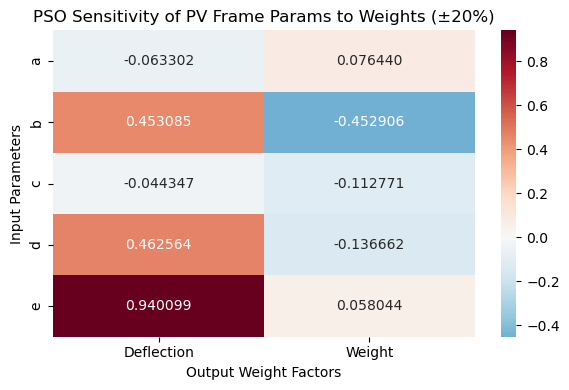

[±20%] 변수 a -> 'Weight' 가중치에 가장 민감 (계수: 0.076440)
[±20%] 변수 b -> 'Deflection' 가중치에 가장 민감 (계수: 0.453085)
[±20%] 변수 c -> 'Weight' 가중치에 가장 민감 (계수: -0.112771)
[±20%] 변수 d -> 'Deflection' 가중치에 가장 민감 (계수: 0.462564)
[±20%] 변수 e -> 'Deflection' 가중치에 가장 민감 (계수: 0.940099)


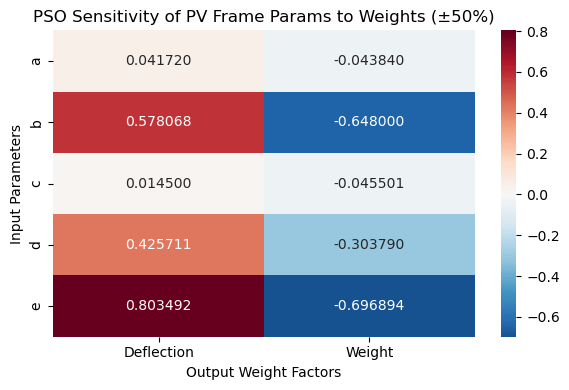

[±50%] 변수 a -> 'Weight' 가중치에 가장 민감 (계수: -0.043840)
[±50%] 변수 b -> 'Weight' 가중치에 가장 민감 (계수: -0.648000)
[±50%] 변수 c -> 'Weight' 가중치에 가장 민감 (계수: -0.045501)
[±50%] 변수 d -> 'Deflection' 가중치에 가장 민감 (계수: 0.425711)
[±50%] 변수 e -> 'Deflection' 가중치에 가장 민감 (계수: 0.803492)


In [7]:

# ----------------------------------------------------
# 6. 최종 결과 요약 출력
# ----------------------------------------------------
X_cols = ['a', 'b', 'c', 'd', 'e']
print("\n=== 최종 PSO 강건성 비교 요약 ===")
print("-----------------------------------------------------------------------------------------")
print("  Tolerance | F_obj Mean | F_obj Std | F_obj CV (%) | X_best Avg CV (%) (a, b, c, d, e)")
print("-----------------------------------------------------------------------------------------")

for df_result in all_pso_analysis_results:
    tolerance = df_result['Tolerance'].iloc[0]
    
    f_obj_mean = df_result['Best_F_obj'].mean()
    f_obj_std = df_result['Best_F_obj'].std()
    f_obj_cv = (f_obj_std / abs(f_obj_mean)) * 100 if f_obj_mean != 0 else 0
    
    x_cvs = [ (df_result[col].std() / abs(df_result[col].mean())) * 100 for col in X_cols if df_result[col].mean() != 0 ]
    avg_x_cv = np.mean(x_cvs) if x_cvs else 0

    print(f"  ±{int(tolerance*100):02d}%     | {f_obj_mean:8.4f}  | {f_obj_std:8.4f} | {f_obj_cv:7.2f}%       | {avg_x_cv:7.2f}%")
print("-----------------------------------------------------------------------------------------")

# ---------------------------------------------------------------------
# 7. 통합 가중치 민감도 분석 시각화 (Heatmap)
# ---------------------------------------------------------------------
WEIGHT_COLS = [f'W_{i+1}' for i in range(2)]
TARGET_NAMES_SHORT = ['Deflection', 'Weight']

print("\n" + "="*65)
print("   🐝 PSO 결과 기반: 입력 변수(a~e) 가중치 민감도 분석 (Regression)")
print("="*65)

for df_res in all_pso_analysis_results:
    t_val = df_res['Tolerance'].iloc[0]
    t_pct = int(t_val * 100)
    
    X_weights = df_res[WEIGHT_COLS]
    
    param_sensitivities = {}
    for param in X_cols:
        model_p = LinearRegression()
        model_p.fit(X_weights, df_res[param])
        param_sensitivities[param] = model_p.coef_
    
    # 데이터프레임 변환 (행: 입력변수 a~e, 열: 가중치 W_1, W_2)
    df_sens = pd.DataFrame(param_sensitivities, index=TARGET_NAMES_SHORT).T
    
    # 히트맵 시각화
    plt.figure(figsize=(6, 4))
    sns.heatmap(df_sens, annot=True, cmap='RdBu_r', center=0, fmt='.6f') 
    plt.title(f'PSO Sensitivity of PV Frame Params to Weights (±{t_pct}%)')
    plt.xlabel('Output Weight Factors')
    plt.ylabel('Input Parameters')
    plt.tight_layout()
    plt.show()

    # 가장 민감한 변수 요약
    for param in X_cols:
        coefs = param_sensitivities[param]
        top_idx = np.argmax(np.abs(coefs))
        print(f"[±{t_pct}%] 변수 {param} -> '{TARGET_NAMES_SHORT[top_idx]}' 가중치에 가장 민감 (계수: {coefs[top_idx]:.6f})")